# PR #17 — Photon Phase-1 recompute tracer bullet

This notebook demos the functionality added in
[PR #17](https://github.com/EBHolm/openbragg/pull/17): the first end-to-end
**dose recompute** path for photon (openkbp-opt) cases.

It walks the full seam introduced by the PR:

1. **`load_case`** — read an openkbp-opt case (`io.openkbp_opt`) into the
   modality-agnostic data model (`model.case`).
2. **`OpenKBPOptEngine.compute_dij`** — the dose-engine seam: turn a `Case`
   into a sparse influence matrix `Dij` (voxels × beamlets) as a `DijResult`
   (`engine.openkbp_opt` / `engine.base`).
3. **`total_dose`** — accumulate `dose = Dij · w` on the grid (`dose.accumulate`).
4. Compare the recompute against the shipped `plan-dose`.

> **Known-answer.** openkbp-opt ships `plan-dose = Dij · w` *by construction*, so
> a correct recompute reproduces it to floating-point precision. That makes this
> an exact plumbing check of the seam — **not** a physics validation (the Dij
> here is synthetic random data, so the dose is noise, not a clinical
> distribution).

### A self-contained synthetic case

The real openkbp-opt dataset is ~10 GB and git-ignored, so this notebook writes
a *tiny* case to a temp dir in openkbp-opt's **exact on-disk format** — the same
`dij.npz`, sparse-CSV `ct`/`dose`, index-only mask CSVs, `voxel_dimensions.csv`,
and `plan-fluence` CSV, just at 16³ voxels instead of 128³. The identical
package API runs on a real `reference-plans/pt_*` directory (with
`--grid 128,128,128`).

In [1]:
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
from scipy import sparse

from openbragg.io.openkbp_opt import load_case
from openbragg.engine.openkbp_opt import OpenKBPOptEngine
from openbragg.dose.accumulate import total_dose

GRID = (16, 16, 16)  # openkbp-opt is (128, 128, 128); tiny here for the demo
N_BEAMLETS = 30

#### Step 1 — write a synthetic openkbp-opt case to disk

In [2]:
def write_synthetic_case(root, grid_shape=GRID, n_beamlets=N_BEAMLETS, seed=0):
    """Write a case in openkbp-opt's on-disk format; return (patient_dir,
    fluence_path, dose_path). plan-dose is Dij @ w by construction."""
    rng = np.random.default_rng(seed)
    n_vox = int(np.prod(grid_shape))

    # Sparse influence matrix Dij (voxels x beamlets) and beamlet weights w.
    dense = rng.uniform(0.0, 1.0, size=(n_vox, n_beamlets))
    dense[dense < 0.85] = 0.0  # ~15% nonzero
    dij = sparse.csr_matrix(dense)
    w = rng.uniform(0.5, 2.0, size=n_beamlets)
    dose = np.asarray(dij @ w).reshape(grid_shape)  # the shipped plan-dose

    def write_vec(path, dense_arr):  # sparse index+value CSV
        flat = dense_arr.reshape(-1)
        idx = np.nonzero(flat)[0]
        pd.DataFrame({"data": flat[idx]}, index=idx).to_csv(path)

    def write_mask(path, mask):  # index-only CSV (all-NaN data)
        idx = np.nonzero(mask.reshape(-1))[0]
        pd.DataFrame({"data": [np.nan] * len(idx)}, index=idx).to_csv(path)

    patient_dir = root / "reference-plans" / "pt_demo"
    patient_dir.mkdir(parents=True, exist_ok=True)
    sparse.save_npz(patient_dir / "dij.npz", dij)

    ct = np.zeros(grid_shape)
    ct.reshape(-1)[: n_vox // 2] = 1000.0
    write_vec(patient_dir / "ct.csv", ct)
    write_vec(patient_dir / "dose.csv", dose)
    np.savetxt(patient_dir / "voxel_dimensions.csv", np.array([3.0, 3.0, 2.5]))

    ptv = np.zeros(grid_shape, bool)
    ptv.reshape(-1)[: n_vox // 8] = True
    cord = np.zeros(grid_shape, bool)
    cord.reshape(-1)[n_vox // 8 : n_vox // 4] = True
    write_mask(patient_dir / "PTV70.csv", ptv)  # names must be openkbp ROIs
    write_mask(patient_dir / "SpinalCord.csv", cord)

    fluence_path = root / "plan-fluence.csv"
    pd.DataFrame(w, columns=["data"]).to_csv(fluence_path)
    return patient_dir, fluence_path, patient_dir / "dose.csv"


root = Path(tempfile.mkdtemp(prefix="openbragg_pr17_"))
patient_dir, fluence_path, dose_path = write_synthetic_case(root)
print("wrote synthetic openkbp-opt case under:", root)
print("patient dir contents:", sorted(p.name for p in patient_dir.iterdir()))

wrote synthetic openkbp-opt case under: /var/folders/89/fdwrf2wd27d4hpqbfc_vsqrc0000gn/T/openbragg_pr17_l87z2trx
patient dir contents: ['PTV70.csv', 'SpinalCord.csv', 'ct.csv', 'dij.npz', 'dose.csv', 'voxel_dimensions.csv']


#### Step 2 — load the case into the data model

In [3]:
case = load_case(patient_dir, fluence_path, dose_path, grid_shape=GRID)

print("identifier       :", case.identifier)
print("grid shape       :", case.image.shape)
print("voxel spacing mm :", case.image.spacing_mm)
print("structures       :", list(case.structures.masks))
print("n beamlets (w)   :", case.plan.weights.shape[0])
print("reference dose   :", "present" if case.reference_dose is not None else "none")

identifier       : pt_demo
grid shape       : (16, 16, 16)
voxel spacing mm : (3.0, 3.0, 2.5)
structures       : ['SpinalCord', 'PTV70']
n beamlets (w)   : 30
reference dose   : present


#### Step 3 — the dose-engine seam: `Case → Dij`

`OpenKBPOptEngine` sources the precomputed `Dij` from disk and validates it
against the case grid and beamlet count. A future *computing* engine drops in
behind this identical `compute_dij` interface — nothing downstream changes.

In [4]:
engine = OpenKBPOptEngine(patient_dir, grid_shape=GRID)
dij_result = engine.compute_dij(case)  # Case -> DijResult (the seam)
dij = dij_result.dij

density = dij.nnz / (dij.shape[0] * dij.shape[1])
print("Dij shape (voxels x beamlets):", dij.shape)
print("Dij nonzeros                 :", dij.nnz)
print(f"Dij density                  : {density:.1%}")
print("units                        :", dij_result.units)

Dij shape (voxels x beamlets): (4096, 30)
Dij nonzeros                 : 18254
Dij density                  : 14.9%
units                        : Gy


#### Step 4 — recompute `dose = Dij · w` and check against `plan-dose`

In [5]:
dose = total_dose(dij_result, case.plan.weights)  # dose = Dij . w
ref = case.reference_dose.array

max_abs = float(np.max(np.abs(dose - ref)))
print("recomputed dose shape    :", dose.shape)
print(f"recomputed dose max      : {float(dose.max()):.4g} Gy")
print(f"max abs diff vs plan-dose: {max_abs:.3e} Gy")

# plan-dose == Dij . w by construction -> exact to fp precision.
assert max_abs < 1e-9, max_abs
print("\nknown-answer recompute reproduces the shipped plan-dose: PASS")

recomputed dose shape    : (16, 16, 16)
recomputed dose max      : 12.79 Gy
max abs diff vs plan-dose: 3.553e-15 Gy

known-answer recompute reproduces the shipped plan-dose: PASS


#### Step 5 — visualize (synthetic data — plumbing, not physics)

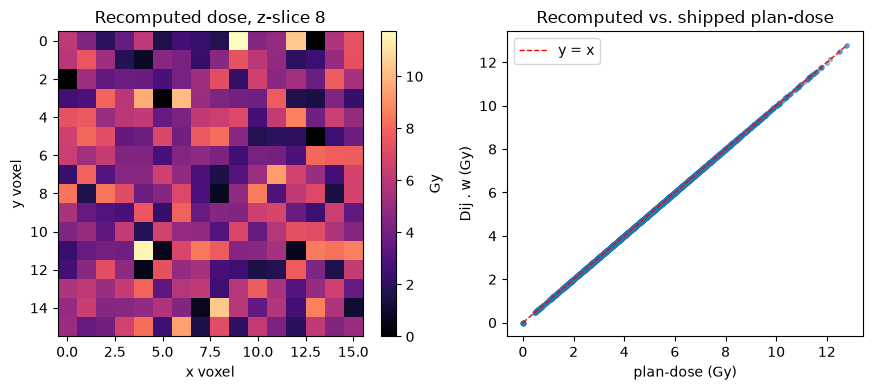

In [6]:
zc = dose.shape[2] // 2
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9, 4))

im = ax0.imshow(dose[:, :, zc], cmap="magma")
ax0.set_title(f"Recomputed dose, z-slice {zc}")
ax0.set_xlabel("x voxel")
ax0.set_ylabel("y voxel")
fig.colorbar(im, ax=ax0, fraction=0.046, label="Gy")

ax1.scatter(ref.reshape(-1), dose.reshape(-1), s=8, alpha=0.4)
lim = [0.0, float(max(ref.max(), dose.max()))]
ax1.plot(lim, lim, "r--", lw=1, label="y = x")
ax1.set_title("Recomputed vs. shipped plan-dose")
ax1.set_xlabel("plan-dose (Gy)")
ax1.set_ylabel("Dij . w (Gy)")
ax1.legend()
fig.tight_layout()
plt.show()

#### Step 5b — every slice at once (montage / lightbox)

The Step-5 view is a single z-slice. To see the whole distribution, tile
**every** axial slice into one figure — the DICOM-viewer "lightbox" — with the
recomputed dose drawn as a translucent colorwash over the grayscale CT and a
single shared Gy colorbar. Dose below 5% of the max is left transparent so the
anatomy shows through. (The synthetic CT here is a flat two-value block, so the
"anatomy" is just contrast — on real openkbp-opt data this is the patient CT.)

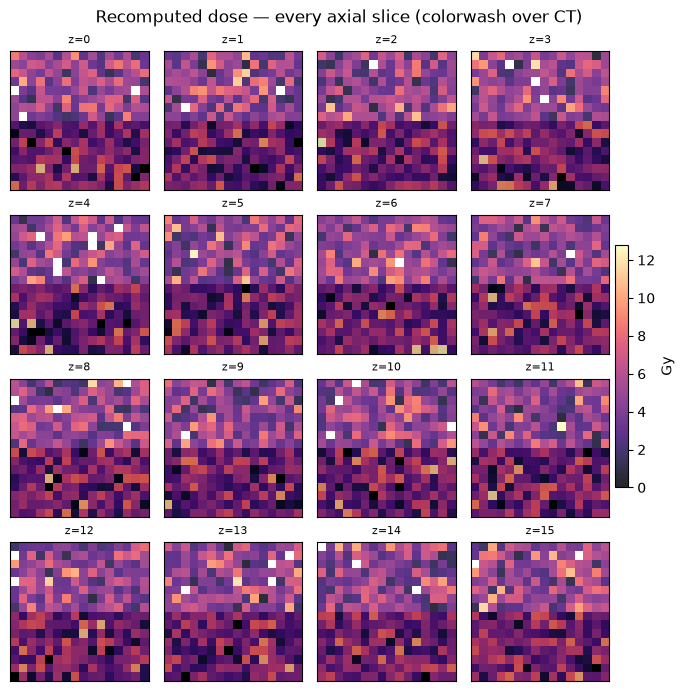

In [7]:
# --- All axial slices at once: dose colorwash over CT (shared Gy colorbar) ---
CMAP = "magma"  # perceptually-uniform sequential ramp (as in Step 5)
DOSE_FLOOR = 0.05  # hide dose < 5% of max so the CT shows through
VMAX = float(dose.max())


def overlay_dose(ax, z):
    """Draw axial slice z: grayscale CT with a translucent dose colorwash."""
    ax.imshow(case.image.array[:, :, z], cmap="gray")
    masked = np.ma.masked_less(dose[:, :, z], DOSE_FLOOR * VMAX)
    im = ax.imshow(masked, cmap=CMAP, vmin=0.0, vmax=VMAX, alpha=0.85)
    ax.set_xticks([])
    ax.set_yticks([])
    return im


nz = dose.shape[2]
ncols = int(np.ceil(np.sqrt(nz)))
nrows = int(np.ceil(nz / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(1.7 * ncols, 1.7 * nrows), constrained_layout=True
)
axes = np.atleast_1d(axes).ravel()
im = None
for z in range(nz):
    im = overlay_dose(axes[z], z)
    axes[z].set_title(f"z={z}", fontsize=8)
for ax in axes[nz:]:
    ax.axis("off")
fig.suptitle("Recomputed dose — every axial slice (colorwash over CT)")
fig.colorbar(im, ax=axes.tolist(), fraction=0.02, pad=0.01, label="Gy")
plt.show()

#### Step 5c — scrub through slices interactively

Same colorwash overlay, one slice at a time, with an `ipywidgets` slider to
scrub through `z`. **Live only:** drag the slider when running this notebook in
a Jupyter kernel. The committed (nbconvert-rendered) output below is a single
static frame — widgets need a running kernel to be interactive.

interactive(children=(IntSlider(value=8, description='z-slice', max=15), Output()), _dom_classes=('widget-inte…

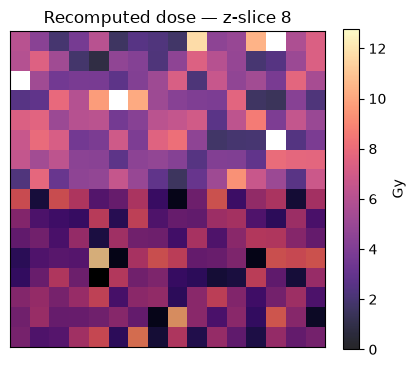

In [8]:
def show_slice(z):
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    im = overlay_dose(ax, z)  # helper defined in the montage cell above
    ax.set_title(f"Recomputed dose — z-slice {z}")
    fig.colorbar(im, ax=ax, fraction=0.046, label="Gy")
    plt.show()


# Live: drag the slider to change slice (needs a running Jupyter kernel).
interact(
    show_slice,
    z=IntSlider(
        min=0, max=dose.shape[2] - 1, value=dose.shape[2] // 2, description="z-slice"
    ),
);

# Static fallback so the committed (nbconvert) output shows a real frame —
# GitHub/nbviewer don't render live widgets. Renders the middle slice.
show_slice(dose.shape[2] // 2)

### The same thing from the CLI

The `recompute` subcommand added by this PR does exactly the above:

```bash
uv run openbragg recompute <patient_dir> \
    --fluence <plan-fluence.csv> \
    --plan-dose <plan-dose.csv> \
    --grid 16,16,16          # omit on real data: default is 128,128,128
```

On the real openkbp-opt dataset, point `patient_dir` at a
`reference-plans/pt_*` directory and drop `--grid`.

**Limits (honest).** This exercises the seam plumbing on a known-answer case; it
is not a physics validation. Validating on the real dataset still needs to
confirm the C-order ravel convention and the dense-fluence assumption in
`load_weights` against actual openkbp-opt files.